# Lab04 Task 1: Unstructured Pruning

In this notebook, you will learn how to apply unstructured pruning in order to reduce the complexity of a neural network model. A pre-trained model will be used as the basis for performing unstructured pruning and subsequent fine-tuning.

<font color="red">**Only add or modify code between `YOUR CODE START` and `YOUR CODE END`. Don’t change anything outside of these markers.**</font>

In [1]:
##### YOUR CODE START #####

# Please fill in your student id here.
student_id = "314510196"

##### YOUR CODE END #####

### Library Import

The libraries you need for this practice are listed below. You can add more if you think they’re necessary. If you’re not sure whether a library is allowed, ask TA in the FB group.

In [2]:
import os
import tqdm
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms, models
import torch.nn.utils.prune as prune
import matplotlib
import matplotlib.pyplot as plt

##### YOUR CODE START #####

# Do you need any additional libraries? If not, you can leave this block empty.

##### YOUR CODE END #####

### Device
If you have GPU available, you should see "cuda" in the following cell.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: %s" % device)

Using device: cuda


### Dataset

In this lab, we will use CIFAR-10 dataset. CIFAR-10 is a widely used image classification dataset consisting of 60,000 color images at 32×32 resolution. It has 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck), with 50,000 training images and 10,000 test images. Due to its small size and balanced categories, CIFAR-10 is commonly used for benchmarking machine learning and computer vision models.

CIFAR-10 has both a training set and a test set. You may further split the training set to create a validation set, but <font color="red">**it is strictly forbidden to use any images in test set for model training.**</font>

In [4]:
# Load test set

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

Files already downloaded and verified


In [5]:
# Load train set

##### YOUR CODE START #####
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_train)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

##### YOUR CODE END #####

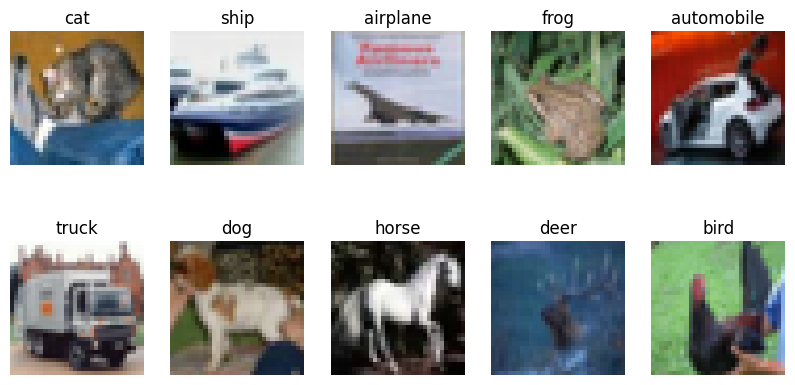

In [6]:
# Let's see some image samples in CIFAR-10 dataset.

def show_img():
    classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
    seen = set()
    images = []
    labels = []
    for img, label in testset:
        if label not in seen:
            seen.add(label)
            images.append(img)
            labels.append(classes[label])
        if len(seen) == len(classes):
            break
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2023, 0.1994, 0.2010])
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flatten()):
        img = images[i] * std.view(3,1,1) + mean.view(3,1,1)
        img = img.clamp(0, 1)
        img = img.permute(1, 2, 0)
        ax.imshow(img.cpu().numpy())
        ax.set_title(labels[i])
        ax.axis("off")
    plt.show()

show_img()

### Load Model
In this lab, you do not need to train a model from scratch. We will use a pretrained ResNet20 model instead. ResNet is a popular deep learning model for image classification. Its key feature is the use of skip (residual) connections, which make training deep networks easier and more stable.
The code below loads the pre-trained model and evaluates its accuracy on the test set, which should be <font color="red">**92.60%**</font>. Please use this model for the subsequent pruning tasks. <font color="red">**Designing and training your own model is not allowed.**</font>

In [7]:
model = torch.hub.load('chenyaofo/pytorch-cifar-models', 
                       'cifar10_resnet20', pretrained=True).to(device)
model.eval()

Using cache found in /nashome/NVL4/msedalab/m314510196/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [8]:
def test_acc():
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f'Accuracy on CIFAR-10 test set: {acc:.2f}%')
    return acc
    
_ = test_acc()

Accuracy on CIFAR-10 test set: 92.59%


### Sparsity

The function below prints the sparsity of the model, which refers to the proportion of zero-valued parameters in each layer. Since we haven’t pruned the model, the sparsity should be 0% for every layer.

In [9]:
def print_sparsity(model, detail=False):
    zeros_all = 0
    total_all = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight
            zeros = float(torch.sum(weight == 0))
            total = float(weight.nelement())
            zeros_all += zeros
            total_all += total
            sparsity = 100.0 * zeros / total
            if detail:
                print(f"Layer {name}: Sparsity = {sparsity:.2f}% ({int(zeros)}/{int(total)})")
    sparsity = 100.0 * zeros_all / total_all
    print(f"Overall Sparsity = {sparsity:.2f}% ({int(zeros_all)}/{int(total_all)})")
    return sparsity

sparsity = print_sparsity(model, detail=True)

Layer conv1: Sparsity = 0.00% (0/432)
Layer layer1.0.conv1: Sparsity = 0.00% (0/2304)
Layer layer1.0.conv2: Sparsity = 0.00% (0/2304)
Layer layer1.1.conv1: Sparsity = 0.00% (0/2304)
Layer layer1.1.conv2: Sparsity = 0.00% (0/2304)
Layer layer1.2.conv1: Sparsity = 0.00% (0/2304)
Layer layer1.2.conv2: Sparsity = 0.00% (0/2304)
Layer layer2.0.conv1: Sparsity = 0.00% (0/4608)
Layer layer2.0.conv2: Sparsity = 0.00% (0/9216)
Layer layer2.0.downsample.0: Sparsity = 0.00% (0/512)
Layer layer2.1.conv1: Sparsity = 0.00% (0/9216)
Layer layer2.1.conv2: Sparsity = 0.00% (0/9216)
Layer layer2.2.conv1: Sparsity = 0.00% (0/9216)
Layer layer2.2.conv2: Sparsity = 0.00% (0/9216)
Layer layer3.0.conv1: Sparsity = 0.00% (0/18432)
Layer layer3.0.conv2: Sparsity = 0.00% (0/36864)
Layer layer3.0.downsample.0: Sparsity = 0.00% (0/2048)
Layer layer3.1.conv1: Sparsity = 0.00% (0/36864)
Layer layer3.1.conv2: Sparsity = 0.00% (0/36864)
Layer layer3.2.conv1: Sparsity = 0.00% (0/36864)
Layer layer3.2.conv2: Sparsity =

### Pruning & Fine-Tune

Finally, you can prune and fine-tune the model. In this lab, you should achieve <font color="red">**>50% sparsity**</font> while keeping <font color="red">**test accuracy >90%**</font>. An example that prunes 50% of the weights in each layer is provided below. Feel free to push the sparsity higher to earn a better score!

In [ ]:
# here


# --- 2. 定義剪枝計畫 ---
# 每輪剪掉剩餘參數的 50%，總共剪四輪
# pruning_plan = 12
pruning_plan = [0.3,0.2,0.2,0.2,0.2,0.2, 0.2, 0.2, 0.2, 0.2,0.1,0.1]
finetune_epochs = 65
criterion = nn.CrossEntropyLoss()

# --- 3. 逐輪剪枝與微調 ---
for iteration, prune_amount in enumerate(pruning_plan):
    print(f"\n--- Pruning Iteration {iteration + 1} ---")
    print(f"Applying {prune_amount*100}% global pruning...")

    # 收集所有要剪枝的參數
    parameters_to_prune = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))

    # 全域剪枝
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=prune_amount
    )

    # 剪枝後的準確度
    print(f"Accuracy after Pruning")
    _ = test_acc()

    # 微調
    print(f"Fine-tuning for {finetune_epochs} epochs...")
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    for epoch in range(finetune_epochs):
        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()
        #print(f"Iter {iteration+1}, Epoch [{epoch+1}/{finetune_epochs}], Loss: {loss.item():.4f}")

    # 評估微調後的準確度
    model.eval()
    sparsity = print_sparsity(model)
    print(f"Accuracy after Iteration {iteration + 1}:, sparsity = {sparsity})")
    _ = test_acc()

# --- 4. 最後移除遮罩，讓剪枝永久化 ---
print("Making pruning permanent...")
for module in model.modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        if prune.is_pruned(module):
            prune.remove(module, name="weight")

# --- 5. 最終評估 ---
print("All pruning iterations finished.")
model.eval()
print("Final Accuracy after all iterative pruning and fine-tuning:")
final_acc = test_acc()



--- Pruning Iteration 1 ---
Applying 30.0% global pruning...
Accuracy after Pruning
Accuracy on CIFAR-10 test set: 91.97%
Fine-tuning for 60 epochs...
Overall Sparsity = 30.00% (81269/270896)
Accuracy after Iteration 1:, sparsity = 30.000073829070935)
Accuracy on CIFAR-10 test set: 92.47%

--- Pruning Iteration 2 ---
Applying 20.0% global pruning...
Accuracy after Pruning
Accuracy on CIFAR-10 test set: 91.41%
Fine-tuning for 60 epochs...
Overall Sparsity = 44.00% (119194/270896)
Accuracy after Iteration 2:, sparsity = 43.99991140511488)
Accuracy on CIFAR-10 test set: 92.27%

--- Pruning Iteration 3 ---
Applying 20.0% global pruning...
Accuracy after Pruning
Accuracy on CIFAR-10 test set: 89.26%
Fine-tuning for 60 epochs...
Overall Sparsity = 55.20% (149534/270896)
Accuracy after Iteration 3:, sparsity = 55.19978146595003)
Accuracy on CIFAR-10 test set: 92.29%

--- Pruning Iteration 4 ---
Applying 20.0% global pruning...
Accuracy after Pruning
Accuracy on CIFAR-10 test set: 88.72%
Fine

In [11]:
# Let's see the result.
acc = test_acc()
sparsity = print_sparsity(model)

print("\n===========================================\n")

if acc < 90.0:
    print("Oh no! Your test accuracy is too low!")
if sparsity < 50.0:
    print("Oh no! Your sparsity is too low!")
if acc >= 90.0 and sparsity >= 50.0:
    print("Congratulations! You've achieved the goals of this task. Remember to save your model!")
    print("You can also try increasing sparsity further to earn a higher score!")

Accuracy on CIFAR-10 test set: 90.11%
Overall Sparsity = 92.39% (250281/270896)


Congratulations! You've achieved the goals of this task. Remember to save your model!
You can also try increasing sparsity further to earn a higher score!


### Save Model

You can use the code below to save your model as `model_[student_id].pt`, where `[student_id]` is replaced by your student ID in the first cell of this notebook.

In [12]:
# Remove mask generated by torch.nn.utils.prune before saving, otherwise TA wouldn't be able to laod your model.
for module in model.modules():
    if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
        if prune.is_pruned(module):
            prune.remove(module, 'weight')
file_name = student_id + "_pruning.pt"
# Save model.state_dict() instead of the entire model.
torch.save(model.state_dict(), file_name)
print("Your model is saved to \"" + file_name + "\".")

Your model is saved to "314510196_pruning.pt".


### Final Check

TA has provided check_pruning.py for students to check if their models can pass the tests. <font color="red">**Please make sure to check it before submission.**</font>

In [13]:
!python check_pruning.py --path {file_name}

Files already downloaded and verified
Congratulations! You've achieved the goals of this task.
Your model's sparsity is 92.39%.
